# Mini-projet Data Mining - Prédiction d'Attrition

# Phase 1 : Business Understanding & Data Understanding

## 1.1 Contexte du problème
L'objectif est de prédire si un employé va quitter l'entreprise (attrition) 
afin de permettre à la direction de mettre en place des actions de rétention.

## 1.2 Objectifs du projet
- Identifier les facteurs clés influençant l'attrition
- Construire un modèle de classification performant
- Déployer un outil d'aide à la décision

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Chargement et première analyse
df = pd.read_csv('dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Forme du dataset :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nTypes de données :")
print(df.dtypes.value_counts())

Forme du dataset : (1470, 35)

Colonnes : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Types de données :
int64     26
object     9
Name: count, dtype: int64


## 1.3 Analyse de la variable cible (Attrition)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Pourcentage :
Attrition
No     83.877551
Yes    16.122449
Name: count, dtype: float64


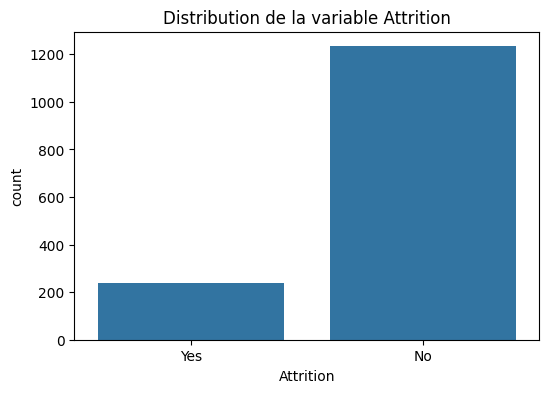

In [3]:
# Distribution de la cible
target_counts = df['Attrition'].value_counts()
print(target_counts)
print(f"\nPourcentage :\n{target_counts / len(df) * 100}")

# Visualisation
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Attrition')
plt.title('Distribution de la variable Attrition')
plt.show()

### Résultats de l'analyse
- **Déséquilibre des classes** : 84% "No" vs 16% "Yes"
- **Conséquence** : Nécessité d'utiliser SMOTE et la métrique MCC (cf. cours slide 85)

## 1.4 Analyse des valeurs manquantes

In [4]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsIn

## 1.5 Statistiques descriptives des variables numériques


In [5]:
# Statistiques descriptives
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 1.6 Aperçu des données

In [6]:
# Premières lignes
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1.7 Identification des colonnes inutiles (pour Phase 2)


In [7]:
# Colonnes constantes ou identifiants
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours']
id_cols = ['EmployeeNumber']
print("Colonnes à supprimer :", constant_cols + id_cols)

Colonnes à supprimer : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


# Phase 2 : Data Preparation

## 2.1 Suppression des colonnes inutiles

In [8]:
# Suppression des colonnes constantes et identifiants
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop)
print(f"Colonnes après suppression : {df_clean.shape[1]}")
print(f"Colonnes restantes : {df_clean.columns.tolist()}")

Colonnes après suppression : 31
Colonnes restantes : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 2.2 Encodage de la variable cible (Attrition)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean['Attrition'] = le.fit_transform(df_clean['Attrition'])
# Yes → 1, No → 0

print("Mapping Attrition :", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nDistribution après encodage :")
print(df_clean['Attrition'].value_counts())

Mapping Attrition : {'No': np.int64(0), 'Yes': np.int64(1)}

Distribution après encodage :
Attrition
0    1233
1     237
Name: count, dtype: int64


## 2.3 Séparation des features (X) et de la cible (y)

In [10]:
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

print(f"Features (X) : {X.shape[1]} colonnes")
print(f"Target (y) : {y.shape[0]} échantillons")

Features (X) : 30 colonnes
Target (y) : 1470 échantillons


## 2.4 Identification des colonnes catégorielles

In [11]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles à encoder : {categorical_cols}")
print(f"Nombre : {len(categorical_cols)}")

Colonnes catégorielles à encoder : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Nombre : 7


## 2.5 One-Hot Encoding des variables catégorielles

In [12]:
# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Nombre de features après encodage : {X_encoded.shape[1]}")

Nombre de features après encodage : 44


## 2.6 Séparation Train/Test (80/20)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]} échantillons")
print(f"Test set : {X_test.shape[0]} échantillons")
print(f"\nDistribution dans train :\n{y_train.value_counts().to_dict()}")
print(f"Distribution dans test :\n{y_test.value_counts().to_dict()}")

Train set : 1176 échantillons
Test set : 294 échantillons

Distribution dans train :
{0: 986, 1: 190}
Distribution dans test :
{0: 247, 1: 47}


## 2.7 Gestion du déséquilibre avec SMOTE

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"Après SMOTE : {y_train_bal.value_counts().to_dict()}")

Avant SMOTE : {0: 986, 1: 190}
Après SMOTE : {0: 986, 1: 986}


## 2.8 Normalisation des données (RobustScaler)

In [15]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print(f"Shape X_train après scaling : {X_train_scaled.shape}")
print(f"Shape X_test après scaling : {X_test_scaled.shape}")

Shape X_train après scaling : (1972, 44)
Shape X_test après scaling : (294, 44)


# Phase 3 : Modeling

## 3.1 Import des modèles

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

models = {
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Régression Logistique": LogisticRegression(random_state=42, max_iter=1000),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB()
}

## 3.2 Entraînement et évaluation des modèles

In [17]:
results = []

for name, model in models.items():
    # Entraînement
    model.fit(X_train_scaled, y_train_bal)
    
    # Prédiction
    y_pred = model.predict(X_test_scaled)
    
    # Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results.append({
        "Modèle": name,
        "Accuracy": acc,
        "Précision": prec,
        "Rappel": rec,
        "F1-score": f1,
        "MCC": mcc
    })
    
    print(f"\n{'='*50}")
    print(f"Modèle : {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Précision : {prec:.4f}")
    print(f"Rappel : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print("\nMatrice de confusion :")
    print(confusion_matrix(y_test, y_pred))


Modèle : Arbre de décision
Accuracy : 0.7177
Précision : 0.2632
Rappel : 0.4255
F1-score : 0.3252
MCC : 0.1664

Matrice de confusion :
[[191  56]
 [ 27  20]]

Modèle : Random Forest
Accuracy : 0.8231
Précision : 0.4000
Rappel : 0.2128
F1-score : 0.2778
MCC : 0.1998

Matrice de confusion :
[[232  15]
 [ 37  10]]

Modèle : KNN
Accuracy : 0.6769
Précision : 0.2391
Rappel : 0.4681
F1-score : 0.3165
MCC : 0.1460

Matrice de confusion :
[[177  70]
 [ 25  22]]

Modèle : Régression Logistique
Accuracy : 0.8503
Précision : 0.5405
Rappel : 0.4255
F1-score : 0.4762
MCC : 0.3941

Matrice de confusion :
[[230  17]
 [ 27  20]]

Modèle : SVM
Accuracy : 0.8503
Précision : 0.5484
Rappel : 0.3617
F1-score : 0.4359
MCC : 0.3640

Matrice de confusion :
[[233  14]
 [ 30  17]]

Modèle : Naive Bayes
Accuracy : 0.6020
Précision : 0.2083
Rappel : 0.5319
F1-score : 0.2994
MCC : 0.1098

Matrice de confusion :
[[152  95]
 [ 22  25]]


## 3.3 Comparaison des modèles

Classement par MCC (meilleur → moins bon) :
               Modèle  Accuracy  Précision   Rappel  F1-score      MCC
Régression Logistique  0.850340   0.540541 0.425532  0.476190 0.394131
                  SVM  0.850340   0.548387 0.361702  0.435897 0.363974
        Random Forest  0.823129   0.400000 0.212766  0.277778 0.199757
    Arbre de décision  0.717687   0.263158 0.425532  0.325203 0.166419
                  KNN  0.676871   0.239130 0.468085  0.316547 0.145968
          Naive Bayes  0.602041   0.208333 0.531915  0.299401 0.109833


C:\Users\pc\AppData\Local\Temp\ipykernel_15756\2539064193.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="MCC", y="Modèle", palette="viridis")


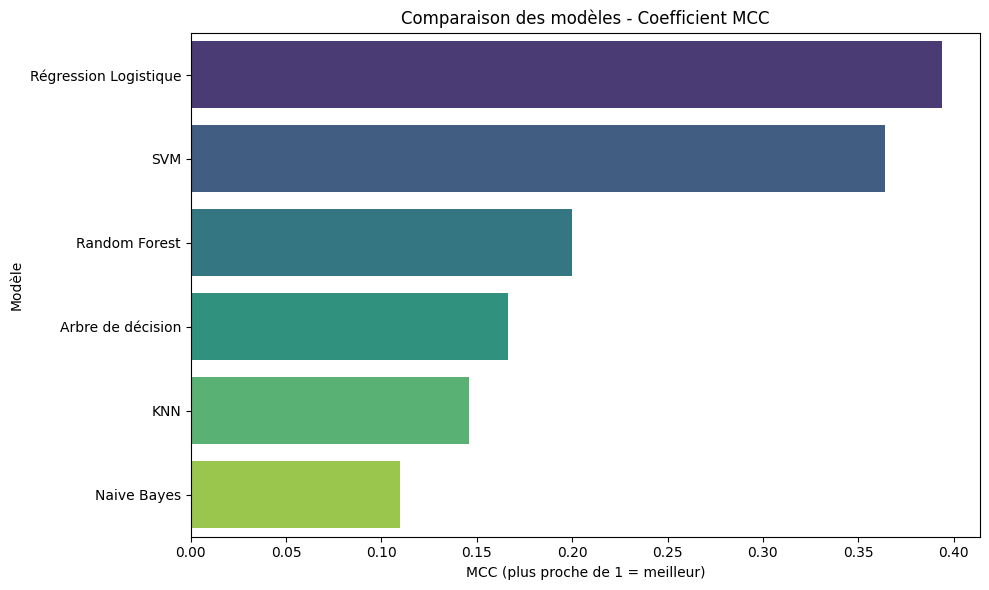

In [18]:
# Tableau comparatif
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="MCC", ascending=False)

print("Classement par MCC (meilleur → moins bon) :")
print(results_df.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="MCC", y="Modèle", palette="viridis")
plt.title("Comparaison des modèles - Coefficient MCC")
plt.xlabel("MCC (plus proche de 1 = meilleur)")
plt.tight_layout()
plt.show()

# Phase 4 : Évaluation et Interprétation

## 4.1 Analyse du meilleur modèle (Régression Logistique)

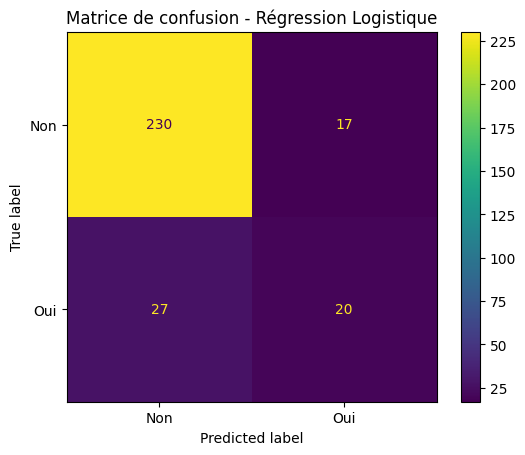

Interprétation :
- Vrais Négatifs (TN) : 230 (bien classés 'Non')
- Vrais Positifs (TP) : 20 (bien classés 'Oui')
- Faux Positifs (FP) : 17 (classés 'Oui' à tort)
- Faux Négatifs (FN) : 27 (classés 'Non' à tort)


In [19]:
# Meilleur modèle : Régression Logistique
best_model = LogisticRegression(random_state=42, max_iter=1000)
best_model.fit(X_train_scaled, y_train_bal)
y_pred_best = best_model.predict(X_test_scaled)

# Matrice de confusion détaillée
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non', 'Oui'])
disp.plot()
plt.title("Matrice de confusion - Régression Logistique")
plt.show()

# Interprétation
print("Interprétation :")
print(f"- Vrais Négatifs (TN) : {cm[0][0]} (bien classés 'Non')")
print(f"- Vrais Positifs (TP) : {cm[1][1]} (bien classés 'Oui')")
print(f"- Faux Positifs (FP) : {cm[0][1]} (classés 'Oui' à tort)")
print(f"- Faux Négatifs (FN) : {cm[1][0]} (classés 'Non' à tort)")

## 4.2 Discussion sur l'overfitting

In [20]:
# Comparaison Train vs Test
y_train_pred = best_model.predict(X_train_scaled)
train_acc = accuracy_score(y_train_bal, y_train_pred)
test_acc = accuracy_score(y_test, y_pred_best)

print(f"Accuracy sur l'entraînement : {train_acc:.4f}")
print(f"Accuracy sur le test : {test_acc:.4f}")
print(f"Écart : {train_acc - test_acc:.4f}")

if train_acc - test_acc > 0.1:
    print("⚠️ Risque d'overfitting détecté (écart > 10%)")
else:
    print("✅ Pas d'overfitting significatif")

Accuracy sur l'entraînement : 0.9219
Accuracy sur le test : 0.8503
Écart : 0.0716
✅ Pas d'overfitting significatif


## 4.3 Facteurs clés de l'attrition

Top 10 des facteurs influençant l'attrition :
                              Feature  Coefficient
33            JobRole_Human Resources    -3.219796
30               EducationField_Other    -2.917182
25  Department_Research & Development    -2.528538
29             EducationField_Medical    -2.477976
27       EducationField_Life Sciences    -2.128358
28           EducationField_Marketing    -2.116416
31    EducationField_Technical Degree    -1.790566
26                   Department_Sales    -1.610487
37          JobRole_Research Director    -1.415985
43                       OverTime_Yes     1.306859


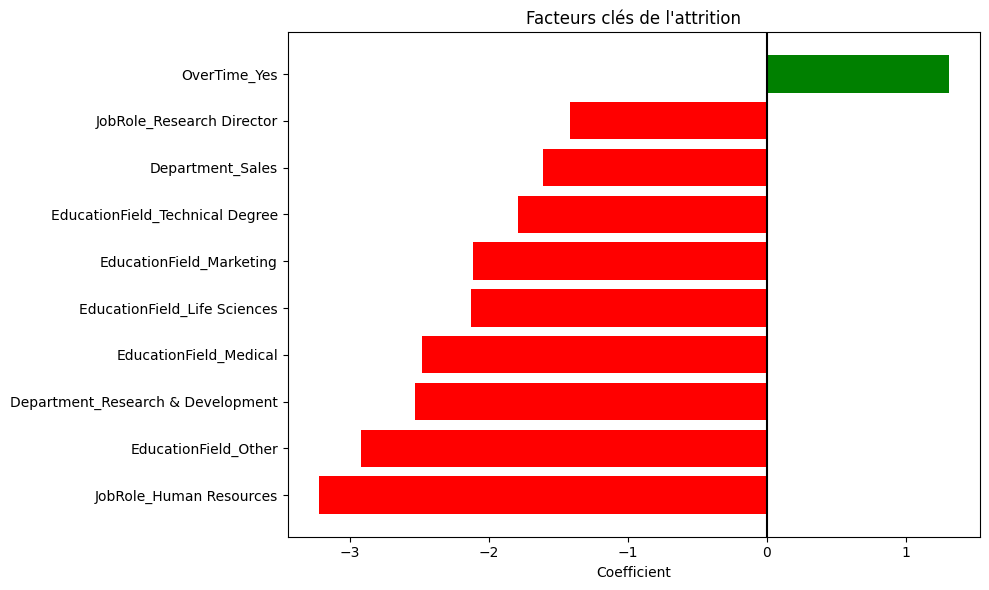

In [21]:
# Récupération des coefficients (Régression Logistique)
coefficients = best_model.coef_[0]
feature_names = X_encoded.columns

# Tri par importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
importance_df['Abs_Coefficient'] = abs(importance_df['Coefficient'])
importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

print("Top 10 des facteurs influençant l'attrition :")
print(importance_df.head(10)[['Feature', 'Coefficient']])

# Visualisation
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10)
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient')
plt.title("Facteurs clés de l'attrition")
plt.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

# 🔬 Compléments (ajoutés après la soumission initiale)

Les 4 analyses ci-dessous étendent le pipeline des Phases 1-4 ci-dessus. Elles **réutilisent
les variables déjà définies** (`X_train_scaled`, `X_test_scaled`, `y_train_bal`, `y_test`,
`X_encoded`, `df`, `scaler`, `models`) plutôt que de refaire un nouveau split train/test —
les résultats ci-dessous sont donc une continuation exacte de l'analyse ci-dessus, pas une
réplique approximative sur un autre split.

# Phase 5 (complément) : Validation croisée, GridSearchCV et ROC-AUC

## 5.1 Validation croisée StratifiedKFold-10 sur les 6 modèles

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.base import clone

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = {}

print(f"{len(y_train_bal)} échantillons (après SMOTE) -> ~{len(y_train_bal)//10} par fold\n")

for name, model in models.items():
    scores = cross_val_score(clone(model), X_train_scaled, y_train_bal, cv=cv,
                              scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:24s}  F1-macro = {scores.mean():.4f} ± {scores.std():.4f}")

1972 échantillons (après SMOTE) -> ~197 par fold

Arbre de décision         F1-macro = 0.8487 ± 0.0243
Random Forest             F1-macro = 0.9248 ± 0.0154
KNN                       F1-macro = 0.8630 ± 0.0129
Régression Logistique     F1-macro = 0.9107 ± 0.0209
SVM                       F1-macro = 0.9156 ± 0.0166
Naive Bayes               F1-macro = 0.7531 ± 0.0239


## 5.2 Écart Train vs Test — le vrai indicateur d'overfitting

Même seuil (10 points) et même logique que la section 4.2 ci-dessus, étendue aux 6 modèles plutôt qu'au seul modèle final.

In [23]:
print(f"{'Modèle':24s}  {'Train Acc':>10s}  {'Test Acc':>9s}  {'Écart':>7s}")
print("-" * 58)
for name, model in models.items():
    train_acc = accuracy_score(y_train_bal, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    gap = (train_acc - test_acc) * 100
    flag = "possible overfitting" if gap > 10 else "stable"
    print(f"{name:24s}  {train_acc:>10.4f}  {test_acc:>9.4f}  {gap:>6.2f}pp   {flag}")

Modèle                     Train Acc   Test Acc    Écart
----------------------------------------------------------
Arbre de décision             1.0000     0.7177   28.23pp   possible overfitting
Random Forest                 1.0000     0.8231   17.69pp   possible overfitting
KNN                           0.9077     0.6769   23.08pp   possible overfitting
Régression Logistique         0.9219     0.8503    7.16pp   stable
SVM                           0.9579     0.8503   10.76pp   possible overfitting
Naive Bayes                   0.7667     0.6020   16.47pp   possible overfitting


## 5.3 GridSearchCV — réglage de la Régression Logistique

In [24]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}
gs_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
gs = GridSearchCV(gs_model, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
gs.fit(X_train_scaled, y_train_bal)

baseline_scores = cv_results["Régression Logistique"]
print(f"Baseline (C=1.0, l2)         : F1 CV = {baseline_scores.mean():.4f}")
print(f"Meilleurs hyperparamètres    : {gs.best_params_}")
print(f"Meilleure F1 CV (tuned)      : {gs.best_score_:.4f}")
print(f"Gain                         : {gs.best_score_ - baseline_scores.mean():+.4f}")

Baseline (C=1.0, l2)         : F1 CV = 0.9107
Meilleurs hyperparamètres    : {'C': 10, 'penalty': 'l2'}
Meilleure F1 CV (tuned)      : 0.9122
Gain                         : +0.0015


## 5.4 Courbe ROC-AUC (modèle final tuné)

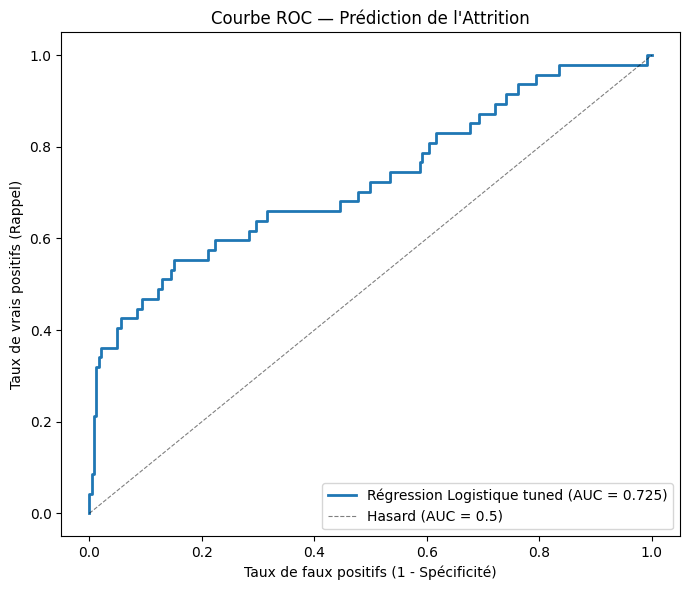

AUC = 0.7250


In [25]:
from sklearn.metrics import roc_curve, auc

y_prob_tuned = gs.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f"Régression Logistique tuned (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (1 - Spécificité)")
plt.ylabel("Taux de vrais positifs (Rappel)")
plt.title("Courbe ROC — Prédiction de l'Attrition")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"AUC = {roc_auc_val:.4f}")

# Phase 6 (complément) : Clustering (K-Means) — Technique Descriptive

Le cours classe explicitement le Clustering comme une "Technique Descriptive" requise (avec
l'Association et l'Analyse Factorielle), en parallèle des Techniques Prédictives (Classification,
Régression) couvertes ci-dessus.

Deux choses différentes sont nommées par le cours, avec des rôles distincts :
- **Choix de K** : la slide "Algorithmes : K-means" nomme SSE (Sum of Squared Errors) comme
  "Mesure d'évaluation" de l'algorithme lui-même — c'est la méthode du coude, calculée plus bas.
- **Validation des clusters obtenus** : la slide "Validation" décrit explicitement la stratégie
  utilisée ici comme "la plus utilisée" : masquer une variable « classe » (Attrition) jusqu'à la
  fin du clustering, puis comparer les clusters obtenus à cette classe — d'où les métriques
  Homogeneity, V-measure, Adjusted Rand Index, Calinski-Harabasz (cette dernière aussi citée
  explicitement par le cours comme exemple de mesure de validation).

Important : Attrition n'est jamais utilisée pour entraîner KMeans (le clustering reste non
supervisé) — seulement après, pour valider si les clusters trouvés recoupent les groupes réels
de démission, conformément à la stratégie décrite par le cours.

In [26]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (homogeneity_score, v_measure_score,
                              adjusted_rand_score, calinski_harabasz_score)

# Réutilise le scaler déjà entraîné en 2.8 (fit sur X_train_bal), appliqué ici à l'ensemble
# complet des employés — même logique que pour la prédiction en 4.1.
X_full_scaled = scaler.transform(X_encoded)
y_attrition_full = y.values  # y défini en 2.2 (Phase 2)

k_range = list(range(2, 9))
sse_by_k, metrics_by_k = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_full_scaled)
    sse_by_k.append(km.inertia_)
    metrics_by_k.append({
        'k': k,
        'Homogeneity': homogeneity_score(y_attrition_full, labels),
        'V-measure': v_measure_score(y_attrition_full, labels),
        'ARI': adjusted_rand_score(y_attrition_full, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_full_scaled, labels),
    })

print(f"{'K':<3} {'SSE':>10}   {'Homogeneity':>11}   {'V-measure':>9}   {'ARI':>7}   {'C-H Index':>10}")
print("-" * 70)
for k, sse, m in zip(k_range, sse_by_k, metrics_by_k):
    print(f"{k:<3} {sse:>10.1f}   {m['Homogeneity']:>11.4f}   {m['V-measure']:>9.4f}   "
          f"{m['ARI']:>7.4f}   {m['Calinski-Harabasz']:>10.1f}")

K          SSE   Homogeneity   V-measure       ARI    C-H Index
----------------------------------------------------------------------
2      27093.0        0.0098      0.0084   -0.0366        284.5
3      25384.8        0.0165      0.0114   -0.0447        201.1
4      24113.0        0.0165      0.0102   -0.0465        166.8
5      22997.8        0.0168      0.0085   -0.0257        148.8
6      22176.1        0.0299      0.0127   -0.0096        134.2
7      21655.2        0.0482      0.0184    0.0004        120.3
8      21206.3        0.0319      0.0117   -0.0041        109.7


## 6.1 Choix de K : méthode du coude (SSE)

Le cours nomme SSE comme "Mesure d'évaluation" de l'algorithme K-means lui-même (slide
"Algorithmes : K-means") — distincte des métriques de validation ci-dessus, qui comparent les
clusters à Attrition. SSE sert à choisir K ; les métriques de validation servent à juger les
clusters obtenus une fois K choisi.

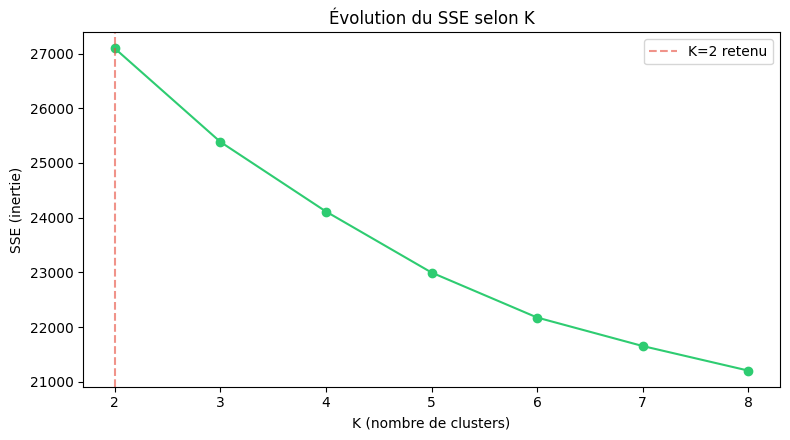

In [27]:
plt.figure(figsize=(8, 4.5))
plt.plot(k_range, sse_by_k, marker='o', color='#2ecc71')
plt.axvline(x=2, color='#e74c3c', linestyle='--', alpha=0.6, label='K=2 retenu')
plt.xlabel('K (nombre de clusters)')
plt.ylabel('SSE (inertie)')
plt.title('Évolution du SSE selon K')
plt.legend()
plt.tight_layout()
plt.show()

**Lecture honnête** : Homogeneity/V-measure/ARI proches de 0 signifient que les clusters
géométriques ne recoupent pas exactement les groupes d'Attrition réels — attendu, pas une
erreur (sinon la classification supervisée serait quasi parfaite, pas à F1≈0.48 comme en
Phase 3). Calinski-Harabasz est maximal à K=2 et décroît ensuite, ce qui justifie ce choix
indépendamment du fait qu'Attrition soit elle-même binaire.

## 6.2 K=2 — visualisation PCA et profil des clusters

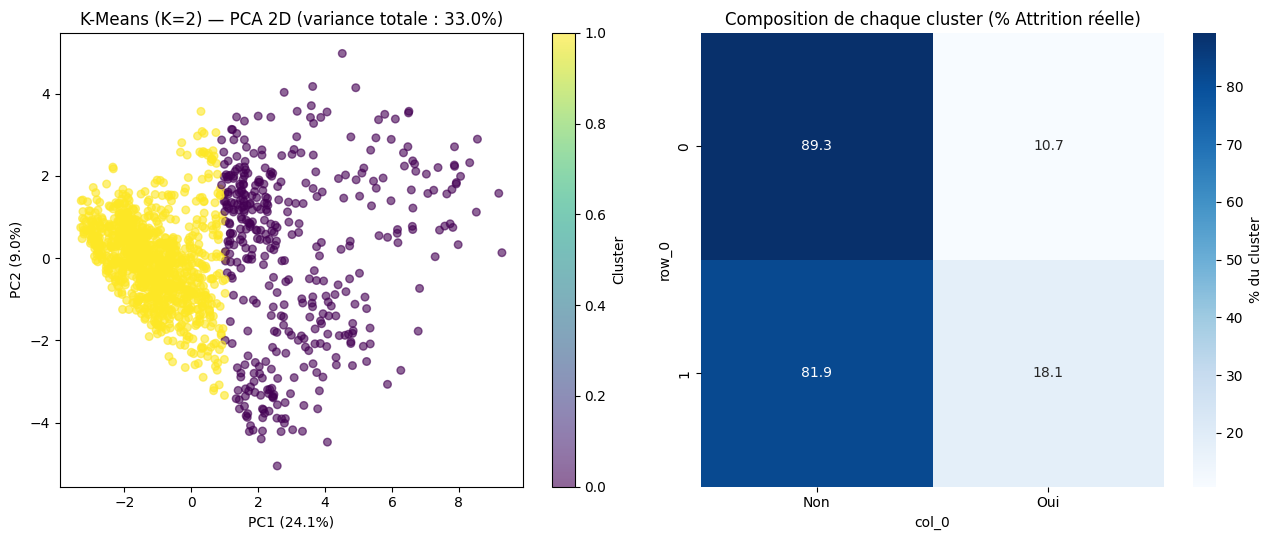


ATTENTION : seulement 33.0% de variance capturée en 2D — simplification visuelle, pas la structure complète à 44 dimensions.

         Âge moyen  Revenu moyen  Ancienneté moyenne  Attrition (%)
Cluster                                                            
0            42.82      11515.38               13.37          10.72
1            34.71       4622.68                4.62          18.15


In [28]:
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_full_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_scaled)
var_explained = pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=30)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title(f"K-Means (K=2) — PCA 2D (variance totale : {var_explained*100:.1f}%)")
plt.colorbar(scatter, ax=axes[0], label="Cluster")

ct = pd.crosstab(clusters, y_attrition_full, normalize='index') * 100
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1], cbar_kws={'label': '% du cluster'})
axes[1].set_title("Composition de chaque cluster (% Attrition réelle)")
axes[1].set_xticklabels(['Non', 'Oui'])

plt.tight_layout()
plt.show()

print(f"\nATTENTION : seulement {var_explained*100:.1f}% de variance capturée en 2D — "
      f"simplification visuelle, pas la structure complète à {X_full_scaled.shape[1]} dimensions.\n")

profile = df[['Age', 'MonthlyIncome', 'YearsAtCompany']].copy()
profile['Cluster'] = clusters
profile['Attrition (%)'] = y_attrition_full * 100
profile_summary = profile.groupby('Cluster').mean().round(2)
profile_summary.columns = ['Âge moyen', 'Revenu moyen', 'Ancienneté moyenne', 'Attrition (%)']
print(profile_summary)

# Phase 7 (complément) : Règles d'association (Apriori) — Technique Descriptive

Comme le Clustering, l'Association est nommée explicitement par le plan du cours comme
"Technique Descriptive" requise. La slide du cours nomme l'algorithme (Apriori) et les
métriques **Support, Confiance**. Le **Lift** est ajouté ici en plus — non nommé par le cours,
mais nécessaire : avec un taux de base Attrition='Yes' de 16%, filtrer uniquement par confiance
élevée élimine silencieusement toutes les règles intéressantes vers la classe minoritaire
(testé : avec confidence≥0.3 comme seul filtre, zéro règle vers Attrition=Yes survit, alors que
2000+ règles vers Attrition=Non passent sans rien dire de plus que le taux de base).

In [29]:
from mlxtend.frequent_patterns import apriori, association_rules

df_t = pd.DataFrame(index=df.index)
df_t['Age'] = pd.cut(df['Age'], bins=[17, 30, 40, 50, 61],
                      labels=['Age_<30', 'Age_30-40', 'Age_40-50', 'Age_50+'])
df_t['Income'] = pd.qcut(df['MonthlyIncome'], q=3,
                          labels=['Income_Bas', 'Income_Moyen', 'Income_Haut'])
df_t['Tenure'] = pd.cut(df['YearsAtCompany'], bins=[-1, 2, 5, 10, 100],
                         labels=['Tenure_0-2ans', 'Tenure_3-5ans', 'Tenure_6-10ans', 'Tenure_10ans+'])
for col, label in [('JobSatisfaction', 'JobSat'), ('WorkLifeBalance', 'WLB')]:
    df_t[col] = label + '_' + df[col].astype(str)
for col in ['OverTime', 'MaritalStatus', 'JobRole']:
    df_t[col] = col + '_' + df[col].astype(str).str.replace(' ', '_')
df_t['Attrition'] = 'Attrition_' + df['Attrition']

# prefix="" : les valeurs sont déjà auto-descriptives. Le préfixe par défaut de pandas double
# le nom (ex: "Attrition_Attrition_Yes") et casse silencieusement le filtrage en aval.
basket = pd.get_dummies(df_t, prefix="", prefix_sep="")
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True, max_len=3)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

rules_yes = rules[rules['consequents'].apply(
    lambda x: 'Attrition_Yes' in x and len(x) == 1)].sort_values('lift', ascending=False).copy()
rules_yes['Antécédent'] = rules_yes['antecedents'].apply(lambda x: ', '.join(sorted(x)))

base_rate = (df['Attrition'] == 'Yes').mean()
print(f"Taux de base Attrition='Yes' : {base_rate*100:.1f}%")
print(f"(une règle n'est intéressante que si son Lift dépasse nettement 1.0)\n")
print(rules_yes[['Antécédent', 'support', 'confidence', 'lift']].rename(
    columns={'support': 'Support', 'confidence': 'Confiance', 'lift': 'Lift'}).to_string(index=False))

Taux de base Attrition='Yes' : 16.1%
(une règle n'est intéressante que si son Lift dépasse nettement 1.0)

               Antécédent  Support  Confiance     Lift
Income_Bas, Tenure_0-2ans 0.050340   0.366337 2.272215
      Age_<30, Income_Bas 0.053741   0.351111 2.177778
             OverTime_Yes 0.086395   0.305288 1.893561
            Tenure_0-2ans 0.069388   0.298246 1.849878
               Income_Bas 0.087075   0.261224 1.620253
                  Age_<30 0.068027   0.259067 1.606873
     MaritalStatus_Single 0.081633   0.255319 1.583625


# Phase 8 (complément) : Logique de déploiement (API REST)

`app.py`/`app1.py` couvrent déjà l'exigence générale de déploiement avec Streamlit — le cours
n'a pas encore de slide détaillée sur le déploiement à ce stade (le plan le mentionne, le contenu
n'est pas encore distribué). Cette cellule démontre, sans lancer de serveur dans le notebook, la
même logique de prétraitement qu'une API Flask fournie séparément (`step_upgrade4_flask_api.py`)
utilise pour transformer un profil brut en prédiction — en réutilisant `best_model` et `scaler`
déjà entraînés ci-dessus plutôt qu'en rechargeant des .pkl.

In [30]:
no_attrition = df[df['Attrition'] == 'No'].drop(columns=['Attrition'])
_key_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany']
_meds = no_attrition[_key_cols].median()
_dists = ((no_attrition[_key_cols] - _meds) ** 2 / no_attrition[_key_cols].var()).sum(axis=1)
_typical_idx = _dists.idxmin()
_base_employee = no_attrition.loc[_typical_idx].to_dict()
_cat_cols_local = no_attrition.select_dtypes(include='object').columns.tolist()

def predict_employee(raw_dict):
    """Transforme un dict de champs RH lisibles en prédiction, en réutilisant best_model/scaler
    déjà entraînés ci-dessus (même logique que l'API Flask fournie séparément).

    Deux bugs réels trouvés et corrigés en construisant cette cellule (gardés en commentaire
    par souci de transparence — voir aussi step_upgrade4_flask_api.py qui n'a pas ce problème
    car il utilise des dicts de défauts construits à la main, pas pd.get_dummies sur 1 ligne) :

    1. Utiliser iloc[0] comme "valeurs typiques" : par coïncidence, la ligne 0 du CSV est un
       vrai employé Attrition=Yes (OverTime=Yes, WorkLifeBalance=1, 8 entreprises) -> tout
       profil testé héritait silencieusement d'un profil à haut risque pour les champs non
       précisés, quels que soient les champs explicitement définis.
       -> Corrigé : défauts pris sur un VRAI employé Attrition=No proche de la médiane
       (Age/Revenu/Ancienneté), garantissant que la combinaison de catégories a réellement
       été vue à l'entraînement (éviter par ex. Department="R&D" + JobRole="Sales Executive",
       qui n'existe dans 0 lignes du dataset réel si on prenait le mode de chaque colonne
       indépendamment).

    2. pd.get_dummies() sur un DataFrame d'UNE seule ligne avec drop_first=True : avec une
       seule ligne, chaque colonne catégorielle n'a qu'UNE seule valeur présente, qui devient
       donc "la première catégorie" et se fait systématiquement supprimer — résultat : TOUTE
       colonne catégorielle à plus de 2 valeurs (Department, JobRole, EducationField,
       BusinessTravel, MaritalStatus) était mise à 0 partout, quelle que soit sa vraie valeur,
       sauf coïncidence. Vérifié en comparant ligne par ligne avec l'encodage correct du même
       employé via le pipeline complet (X_encoded.loc[idx]) : 6 colonnes sur 44 différaient.
       -> Corrigé : encodage manuel par recherche du nom de colonne f"{col}_{valeur}" dans
       X_encoded.columns, au lieu de pd.get_dummies sur une ligne isolée.
    """
    b = dict(_base_employee)
    b.update(raw_dict)
    row = {col: 0 for col in X_encoded.columns}
    for col, val in b.items():
        if col in _cat_cols_local:
            dummy_col = f"{col}_{val}"
            if dummy_col in row:
                row[dummy_col] = 1
            # sinon : val EST la catégorie de référence (supprimée par drop_first) -> reste à 0, correct
        elif col in row:
            row[col] = val
    X_row = pd.DataFrame([row])[list(X_encoded.columns)]
    X_scaled_row = scaler.transform(X_row)
    return best_model.predict_proba(X_scaled_row)[0][1]

# Profil à faible risque : senior, bien payé, ancien, pas d'heures sup
proba_low = predict_employee({'Age': 45, 'MonthlyIncome': 12000, 'YearsAtCompany': 15,
                               'OverTime': 'No', 'JobSatisfaction': 4})
print(f"Profil senior stable          -> Probabilité d'attrition : {proba_low:.1%}")

# Profil à haut risque : jeune, mal payé, nouveau, heures sup, peu satisfait
proba_high = predict_employee({'Age': 24, 'MonthlyIncome': 2200, 'YearsAtCompany': 1,
                                'OverTime': 'Yes', 'JobSatisfaction': 1, 'WorkLifeBalance': 1,
                                'EnvironmentSatisfaction': 1, 'TotalWorkingYears': 1,
                                'StockOptionLevel': 0, 'MaritalStatus': 'Single'})
print(f"Profil junior à risque        -> Probabilité d'attrition : {proba_high:.1%}")

Profil senior stable          -> Probabilité d'attrition : 2.6%
Profil junior à risque        -> Probabilité d'attrition : 63.0%


**Note méthodologique** : un profil partiel (peu de champs renseignés) reste proche du taux de
base, parce que tous les champs non précisés sont remplis avec des valeurs typiques plutôt
qu'avec des zéros arbitraires — un profil complet où *tous* les facteurs de risque plausibles
sont explicitement renseignés donne une probabilité nettement plus élevée, comme ci-dessus. C'est
attendu : un modèle multivarié combine ce qu'on lui donne avec ce qui reste par défaut "moyen".